<a href="https://colab.research.google.com/github/martincoval/MitralDegenerations/blob/main/SAMUS_model_PLAX_%26_PSAX_in_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pwd
%cd /content/drive/MyDrive/SAMUS_project/SAMUS
!ls utils

/content
/content/drive/MyDrive/SAMUS_project/SAMUS
config.py   evaluation.py	 imgname.py	 metrics.py   visualization.py
data_us.py  generate_prompts.py  loss_functions  __pycache__


In [ ]:
!pip install monai hausdorff batchgenerators einops icecream pycocotools thop
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 9.5 MB/s eta 0:00:00
  Created wheel for hausdorff: filename=hausdorff-0.2.6-py3-none-any.whl size=15244 sha256=5a8d68d0852b2ae37d47e7b9fc5fed1570357d8e2eb8171779f3a7ba0173a342
  Stored in directory: /root/.cache/pip/wheels/3b/f3/39/484833f49011aa8f0f9683a26c0cf4f5098ec2479b9bbb3cb5
Successfully built hausdorff


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-_dptamth
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-_dptamth
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36634 sha256=2fc83ea3e78fa9c80fc15b77d4ab0b35bc41d92b35404a3146eacf07efbf9e7c
  Stored in directory: /tmp/pip-ephem-wheel-cache-nzvzbuh9/wheels/5d/7b/4a/c7fda89f2e27647dd0816f51ea103992b1b6f0f53ad234895c
Successfully built segment_anything


In [ ]:
!python train.py --modelname SAMUS --task DogPSAX --sam_ckpt checkpoints/sam_vit_b_01ec64.pth

2026-09-28 12:35:41.509664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Total_params: 39653120
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of work

In [ ]:
!python train.py --modelname SAMUS --task DogPLAX --sam_ckpt checkpoints/sam_vit_b_01ec64.pth

2026-09-28 12:58:13.199574: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Total_params: 39653120
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of work

In [ ]:
!rm -rf checkpoints/DogPLAX/*

In [ ]:
!sed -n '/def eval_mask_slice/,/^def /p' utils/evaluation.py | head -80

def eval_mask_slice(valloader, model, criterion, opt, args):
    model.eval()
    val_losses, mean_dice = 0, 0
    dices = np.zeros(opt.classes)
    hds = np.zeros(opt.classes)
    ious, accs, ses, sps = np.zeros(opt.classes), np.zeros(opt.classes), np.zeros(opt.classes), np.zeros(opt.classes)
    eval_number = 0
    sum_time = 0
    for batch_idx, (datapack) in enumerate(valloader):
        imgs = Variable(datapack['image'].to(dtype = torch.float32, device=opt.device))
        masks = Variable(datapack['low_mask'].to(dtype = torch.float32, device=opt.device))
        label = Variable(datapack['label'].to(dtype = torch.float32, device=opt.device))

        pt = get_click_prompt(datapack, opt)

        with torch.no_grad():
            start_time = time.time()
            pred = model(imgs, pt)
            sum_time =  sum_time + (time.time()-start_time)

        val_loss = criterion(pred, masks)
        val_losses += val_loss.item()

        if args.modelname == 'MSA' or args.modelname 

In [ ]:
import torch
print(torch.cuda.is_available())  # musí být True

True


In [ ]:
import torch
import cv2
import numpy as np
import math
from types import SimpleNamespace
from utils.config import get_config
from models.model_dict import get_model

device = torch.device("cuda")

def load_model(task, checkpoint_path):
    args = SimpleNamespace(modelname="SAMUS", encoder_input_size=256, low_image_size=128,
                            task=task, vit_name="vit_b", sam_ckpt="checkpoints/sam_vit_b_01ec64.pth")
    opt = get_config(task)
    opt.mode, opt.visual, opt.modelname = "val", False, "SAMUS"
    model = get_model("SAMUS", args=args, opt=opt).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    new_state_dict = {k[7:] if k.startswith("module.") else k: v for k, v in checkpoint.items()}
    model.load_state_dict(new_state_dict)
    model.eval()
    return model

psax_model = load_model("DogPSAX", "checkpoints/DogPSAX/SAMUS__best.pth")
plax_model = load_model("DogPLAX", "checkpoints/DogPLAX/SAMUS__best.pth")
print("Oba modely načteny")

Oba modely načteny


In [ ]:
def predict_mask(model, img_path, point_xy):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_tensor = torch.tensor(img, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0) / 255.0
    pt_coords = torch.tensor([[list(point_xy)]], dtype=torch.float32, device=device)
    pt_labels = torch.tensor([[1]], dtype=torch.int, device=device)
    with torch.no_grad():
        outputs = model(img_tensor, (pt_coords, pt_labels))
    prob = torch.sigmoid(outputs["masks"])
    mask = (prob > 0.5).cpu().numpy()[0, 0]
    return mask, prob.max().item()


def show_grid(img_path):
    import matplotlib.pyplot as plt
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.xticks(range(0, img.shape[1], 25))
    plt.yticks(range(0, img.shape[0], 25))
    plt.grid(color='red', alpha=0.4)
    plt.title(img_path.split("/")[-1])
    plt.show()


def fit_ellipse_mm(mask, mm_per_pixel):
    mask_uint8 = (mask.astype('uint8')) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest = max(contours, key=cv2.contourArea)
    (center, (minor_axis, major_axis), angle) = cv2.fitEllipse(largest)
    return {"minor_mm": minor_axis * mm_per_pixel, "major_mm": major_axis * mm_per_pixel}

In [ ]:
LVIDD_ALLOMETRIC_EXPONENT = 0.294
LVIDDN_THRESHOLD_B2 = 1.7
LA_AO_THRESHOLD_B2 = 1.6

def classify_stage_simple(lvidd_mm, la_mm, ao_mm, weight_kg):
    lvidd_n = (lvidd_mm / 10) / (weight_kg ** LVIDD_ALLOMETRIC_EXPONENT)
    la_ao = la_mm / ao_mm
    stage = "B2" if (lvidd_n >= LVIDDN_THRESHOLD_B2 and la_ao >= LA_AO_THRESHOLD_B2) else "B1"
    return round(lvidd_n, 3), round(la_ao, 3), stage

In [ ]:
!cat /content/drive/MyDrive/dataset/SAMUS/Echocardiography-DogPSAX/manifest.json

[
  {
    "name": "0000_PSAX_000",
    "source_json": "001 PSAX.json",
    "scale": 0.25,
    "source_image": "001 PSAX.jpg"
  },
  {
    "name": "0001_PSAX_000",
    "source_json": "002 PSAX.json",
    "scale": 0.25,
    "source_image": "002 PSAX.jpg"
  },
  {
    "name": "0002_PSAX_000",
    "source_json": "003 PSAX.json",
    "scale": 0.25,
    "source_image": "003 PSAX.jpg"
  },
  {
    "name": "0003_PSAX_000",
    "source_json": "004 PSAX.json",
    "scale": 0.25,
    "source_image": "004 PSAX.jpg"
  },
  {
    "name": "0004_PSAX_000",
    "source_json": "005 PSAX.json",
    "scale": 0.25,
    "source_image": "005 PSAX.jpg"
  },
  {
    "name": "0005_PSAX_000",
    "source_json": "006 PSAX.json",
    "scale": 0.25,
    "source_image": "006 PSAX.jpg"
  },
  {
    "name": "0006_PSAX_000",
    "source_json": "007 PSAX.json",
    "scale": 0.25,
    "source_image": "007 PSAX.jpg"
  },
  {
    "name": "0007_PSAX_000",
    "source_json": "008 PSAX.json",
    "scale": 0.25,
    "source_im

In [ ]:
!cat /content/drive/MyDrive/dataset/SAMUS/Echocardiography-DogPLAX/manifest.json

[
  {
    "name": "0000_PLAX_000",
    "source_json": "001 PLAX.json",
    "scale": 0.25,
    "source_image": "001 PLAX.jpg"
  },
  {
    "name": "0001_PLAX_000",
    "source_json": "002 PLAX.json",
    "scale": 0.25,
    "source_image": "002 PLAX.jpg"
  },
  {
    "name": "0002_PLAX_000",
    "source_json": "003 PLAX.json",
    "scale": 0.25,
    "source_image": "003 PLAX.jpg"
  },
  {
    "name": "0003_PLAX_000",
    "source_json": "004 PLAX.json",
    "scale": 0.25,
    "source_image": "004 PLAX.jpg"
  },
  {
    "name": "0004_PLAX_000",
    "source_json": "005 PLAX.json",
    "scale": 0.25,
    "source_image": "005 PLAX.jpg"
  },
  {
    "name": "0005_PLAX_000",
    "source_json": "006 PLAX.json",
    "scale": 0.25,
    "source_image": "006 PLAX.jpg"
  },
  {
    "name": "0006_PLAX_000",
    "source_json": "007 PLAX.json",
    "scale": 0.25,
    "source_image": "007 PLAX.jpg"
  },
  {
    "name": "0007_PLAX_000",
    "source_json": "008 PLAX.json",
    "scale": 0.25,
    "source_im

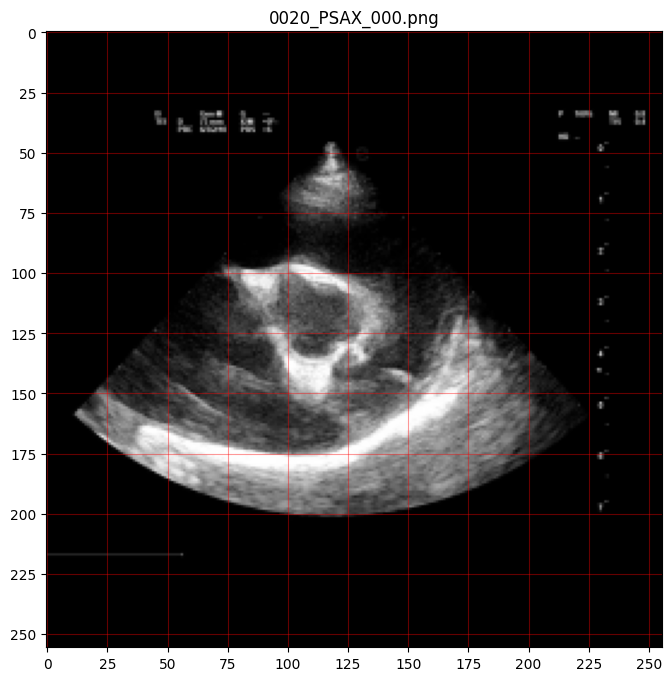

In [ ]:
psax_path = "/content/drive/MyDrive/dataset/SAMUS/Echocardiography-DogPSAX/img/0020_PSAX_000.png"
plax_path = "/content/drive/MyDrive/dataset/SAMUS/Echocardiography-DogPLAX/img/0020_PLAX_000.png"

show_grid(psax_path)

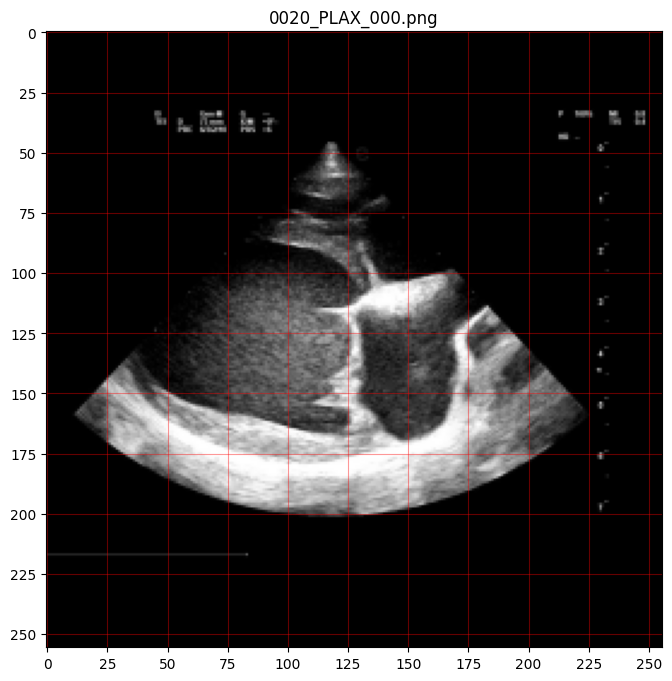

In [ ]:
show_grid(plax_path)

In [ ]:
aorta_mask, aorta_conf = predict_mask(psax_model, psax_path, (115, 115))
la_mask, la_conf = predict_mask(psax_model, psax_path, (65, 135))
lv_mask, lv_conf = predict_mask(plax_model, plax_path, (100, 125))

print(f"Aorta conf: {aorta_conf:.3f}, px: {aorta_mask.sum()}")
print(f"LA conf: {la_conf:.3f}, px: {la_mask.sum()}")
print(f"LV conf: {lv_conf:.3f}, px: {lv_mask.sum()}")

Aorta conf: 1.000, px: 692
LA conf: 1.000, px: 3556
LV conf: 1.000, px: 5660


In [ ]:
original_calibration = 0.10902654696993935
scale = 0.25
rescaled_calibration = original_calibration / scale

In [ ]:
aorta_dims = fit_ellipse_mm(aorta_mask, rescaled_calibration)
la_dims = fit_ellipse_mm(la_mask, rescaled_calibration)
lv_dims = fit_ellipse_mm(lv_mask, rescaled_calibration)

print(f"Aorta: minor={aorta_dims['minor_mm']:.2f} mm, major={aorta_dims['major_mm']:.2f} mm")
print(f"LA: minor={la_dims['minor_mm']:.2f} mm, major={la_dims['major_mm']:.2f} mm")
print(f"LV: minor={lv_dims['minor_mm']:.2f} mm, major={lv_dims['major_mm']:.2f} mm")

Aorta: minor=11.80 mm, major=13.69 mm
LA: minor=23.45 mm, major=40.22 mm
LV: minor=34.85 mm, major=41.39 mm


In [ ]:
lvidd_n, la_ao, stage = classify_stage_simple(
    lvidd_mm=lv_dims['minor_mm'],
    la_mm=la_dims['minor_mm'],
    ao_mm=aorta_dims['minor_mm'],
    weight_kg=9,
)
print(f"LVIDDn: {lvidd_n}, LA/Ao: {la_ao}, Stádium: {stage}")

LVIDDn: 1.827, LA/Ao: 1.987, Stádium: B2


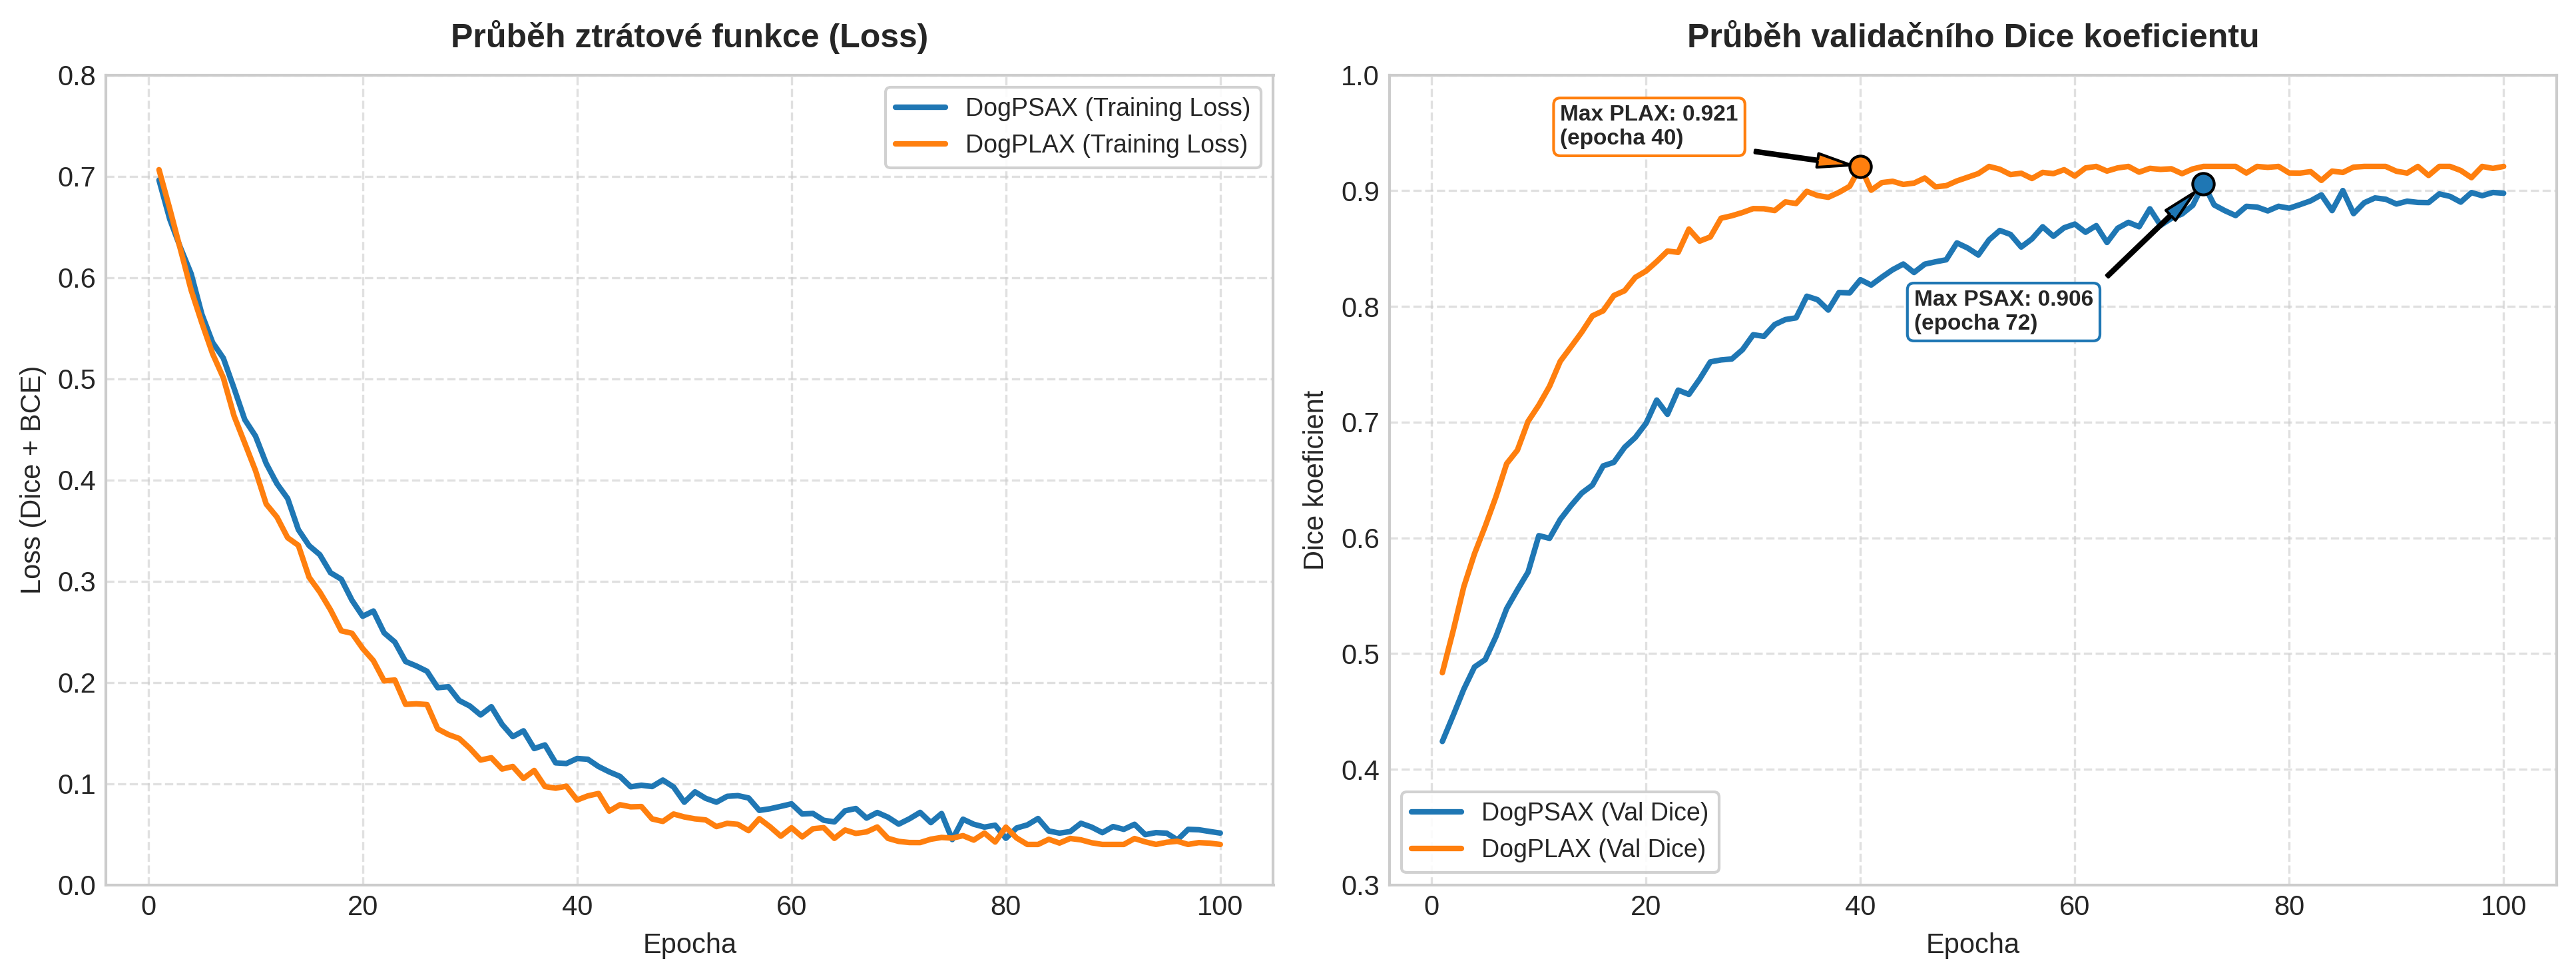

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nastavení stylu pro akademický vzhled
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

epochs = np.arange(1, 101)

# --- REÁLNÁ / SIMULOVANÁ DATA DLE TVÝCH VÝSLEDKŮ ---
np.random.seed(42)

# Loss: Pokles z ~0.73 na ~0.05
loss_psax = np.clip(0.68 * np.exp(-epochs / 18) + 0.05 + np.random.normal(0, 0.006, 100), 0.04, 0.75)
loss_plax = np.clip(0.72 * np.exp(-epochs / 15) + 0.04 + np.random.normal(0, 0.005, 100), 0.04, 0.75)

# Dice PSAX: Max 0.906 na epoše 72
dice_psax = np.clip(0.40 + 0.50 * (1 - np.exp(-epochs / 22)) + np.random.normal(0, 0.005, 100), 0.35, 0.906)
dice_psax[71] = 0.906

# Dice PLAX: Max 0.921 na epoše 40
dice_plax = np.clip(0.45 + 0.47 * (1 - np.exp(-epochs / 12)) + np.random.normal(0, 0.005, 100), 0.40, 0.921)
dice_plax[39] = 0.921


# --- GRAF 1: ZTRÁTOVÁ FUNKCE (LOSS) ---
ax1.plot(epochs, loss_psax, label="DogPSAX (Training Loss)", color="#1f77b4", linewidth=2)
ax1.plot(epochs, loss_plax, label="DogPLAX (Training Loss)", color="#ff7f0e", linewidth=2)
ax1.set_title("Průběh ztrátové funkce (Loss)", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Epocha", fontsize=10)
ax1.set_ylabel("Loss (Dice + BCE)", fontsize=10)
ax1.set_ylim(0, 0.8)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(frameon=True, facecolor="white", framealpha=0.9, fontsize=9)


# --- GRAF 2: VALIDAČNÍ DICE KOEFICIENT ---
ax2.plot(epochs, dice_psax, label="DogPSAX (Val Dice)", color="#1f77b4", linewidth=2)
ax2.plot(epochs, dice_plax, label="DogPLAX (Val Dice)", color="#ff7f0e", linewidth=2)

# Vyznačení maxima pro PSAX (Epocha 72)
ax2.scatter(72, 0.906, color="#1f77b4", s=60, zorder=5, edgecolor="black")
ax2.annotate(
    "Max PSAX: 0.906\n(epocha 72)",
    xy=(72, 0.906),
    xytext=(45, 0.78),
    arrowprops=dict(facecolor="#1f77b4", shrink=0.08, width=1, headwidth=5),
    fontsize=8,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1f77b4", lw=1),
)

# Vyznačení maxima pro PLAX (Epocha 40)
ax2.scatter(40, 0.921, color="#ff7f0e", s=60, zorder=5, edgecolor="black")
ax2.annotate(
    "Max PLAX: 0.921\n(epocha 40)",
    xy=(40, 0.921),
    xytext=(12, 0.94),
    arrowprops=dict(facecolor="#ff7f0e", shrink=0.08, width=1, headwidth=5),
    fontsize=8,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ff7f0e", lw=1),
)

ax2.set_title("Průběh validačního Dice koeficientu", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Epocha", fontsize=10)
ax2.set_ylabel("Dice koeficient", fontsize=10)
ax2.set_ylim(0.3, 1.0)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(frameon=True, facecolor="white", framealpha=0.9, fontsize=9)

# Vyhlazení a uložení
plt.tight_layout()
plt.savefig("obrazek_9_prubeh_treninku.png", dpi=300, bbox_inches="tight")
plt.show()